# NES (Natural Evolution Strategies) Attack

This notebook demonstrates a **gradient estimation** black-box attack based on Natural Evolution Strategies (Ilyas et al., 2018) against three pre-trained CNNs: EfficientNetB0, InceptionV3, and MobileNetV2.

NES answers the question: *what would PGD look like if we never had access to `tape.gradient`?* Instead of backpropagating through the model, it **estimates** the gradient by querying the model at many random points around the current image and using their outputs to reconstruct the direction of steepest ascent, a classic zeroth-order optimization technique. The estimated gradient is then plugged into the exact same sign-step, $\varepsilon$-ball-projected update rule as `attacks/whitebox/02_PGD.ipynb`.


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Import models
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2

# Import specific preprocessing and decoding functions
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff, decode_predictions as decode_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc, decode_predictions as decode_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob, decode_predictions as decode_mob

### Setup Models and Images
We reuse the same `models_dict` / `images_dict` structure as the white-box notebooks. `eps_scale` normalizes the perceptual magnitude of $\varepsilon$ across each model's input range (`[0, 255]` for EfficientNet vs. `[-1, 1]` for MobileNetV2/InceptionV3), following the convention used in `attacks/whitebox/02_PGD.ipynb`.

In [2]:
# Helper functions for denormalization based on model preprocessing
def denormalize_eff(img):
    # EfficientNet uses [0, 255] range
    img = tf.clip_by_value(img, 0, 255)
    return img.numpy().squeeze().astype("uint8")

def denormalize_neg1_1(img):
    # MobileNetV2 and InceptionV3 use [-1, 1] range
    img = (img + 1.0) / 2.0 # Convert to [0, 1]
    img = img * 255.0 # Convert to [0, 255]
    img = tf.clip_by_value(img, 0, 255)
    return img.numpy().squeeze().astype("uint8")

# Dictionary with model configurations
models_dict = {
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_mob,
        'decode_fn': decode_mob,
        'denormalize_fn': denormalize_neg1_1,
        'clip_min': -1.0,
        'clip_max': 1.0,
        'eps_scale': 1.0
    },
    'EfficientNetB0': {
        'model': EfficientNetB0(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_eff,
        'decode_fn': decode_eff,
        'denormalize_fn': denormalize_eff,
        'clip_min': 0.0,
        'clip_max': 255.0,
        'eps_scale': 127.5
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet'),
        'target_size': (299, 299),
        'preprocess_fn': preprocess_inc,
        'decode_fn': decode_inc,
        'denormalize_fn': denormalize_neg1_1,
        'clip_min': -1.0,
        'clip_max': 1.0,
        'eps_scale': 1.0
    }
}

# Freeze weights - black-box attacks never use gradients, but we keep this
# for consistency with the rest of the repo and to speed up inference.
for config in models_dict.values():
    config['model'].trainable = False

# Dictionary for target images. NES's per-query cost (a full model forward pass, no batching) made
# the 2-image sweep time out at 5400s even at the already-reduced query budgets below; reduced to
# 1 image to actually finish.
images_dict = {
    'Dog': '../../images/dog.png',
}

In [3]:
def load_and_preprocess_image(img_path, target_size, preprocess_fn):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_fn(img) # Dynamic preprocessing
    img = tf.expand_dims(img, axis=0) # Add batch dimension
    return img

def get_imagenet_label(prob, decode_fn):
    return decode_fn(prob, top=1)[0][0]

def get_imagenet_class_index(prob):
    return int(tf.argmax(prob, axis=-1).numpy()[0])

def euclidean_distance(img1, img2):
    return np.linalg.norm(np.array(img1) - np.array(img2))

### NES Gradient Estimation
Given the current image $x$, NES estimates $\nabla_x J(x)$ via **antithetic sampling**: for $n/2$ random Gaussian directions $u_i \sim \mathcal{N}(0, I)$, it queries the model at $x + \sigma u_i$ and $x - \sigma u_i$ and combines the loss values into a Monte Carlo gradient estimate:
$$\hat{\nabla}_x J(x) \approx \frac{1}{2\sigma n} \sum_{i=1}^{n/2} \big[J(x + \sigma u_i) - J(x - \sigma u_i)\big] \, u_i$$
This estimate is then used exactly like a real gradient inside a PGD-style loop: $x_{t+1} = \Pi_{x+\mathcal{S}} \left( x_t + \alpha \cdot sign(\hat{\nabla}_x J(x_t)) \right)$. Every sample costs 2 queries to the model, so `population` directly controls the query cost of each gradient step.

In [4]:
def nes_estimate_gradient(input_image, true_idx, current_model, sigma, n_samples, clip_min, clip_max):
    """Estimates the gradient of the loss w.r.t the input using antithetic NES sampling
    (Ilyas et al., 2018): the model is only ever queried for its output probabilities."""
    grad_estimate = tf.zeros_like(input_image)
    n_pairs = n_samples // 2

    for _ in range(n_pairs):
        u = tf.random.normal(shape=input_image.shape)

        img_plus = tf.clip_by_value(input_image + sigma * u, clip_min, clip_max)
        img_minus = tf.clip_by_value(input_image - sigma * u, clip_min, clip_max)

        probs_plus = current_model(img_plus, training=False).numpy().flatten()
        probs_minus = current_model(img_minus, training=False).numpy().flatten()

        # Untargeted loss proxy: negative log-probability of the true class
        loss_plus = -np.log(probs_plus[true_idx] + 1e-12)
        loss_minus = -np.log(probs_minus[true_idx] + 1e-12)

        grad_estimate += (loss_plus - loss_minus) * u

    grad_estimate = grad_estimate / (2 * sigma * n_pairs)
    return grad_estimate, 2 * n_pairs

def nes_attack(input_image, true_idx, current_model, epsilon, clip_min, clip_max,
               query_budget=1000, alpha_fraction=0.2, sigma=0.001, population=20):
    """PGD-style iterative attack where the true gradient is replaced by its NES estimate,
    so backpropagation through the target model is never required."""
    alpha = epsilon * alpha_fraction
    adv_image = tf.identity(input_image)
    queries_used = 0

    while queries_used + population + 1 <= query_budget:
        grad_estimate, q = nes_estimate_gradient(adv_image, true_idx, current_model, sigma, population, clip_min, clip_max)
        queries_used += q

        adv_image = adv_image + alpha * tf.sign(grad_estimate)
        perturbation = tf.clip_by_value(adv_image - input_image, -epsilon, epsilon)
        adv_image = tf.clip_by_value(input_image + perturbation, clip_min, clip_max)

        current_probs = current_model(adv_image, training=False).numpy().flatten()
        queries_used += 1
        if np.argmax(current_probs) != true_idx: # Already misclassified - stop spending queries
            break

    return adv_image, queries_used

### Evaluation Loop
As with Square Attack, $\varepsilon$ is fixed ($0.05 \times$ `eps_scale`) and we instead sweep the **query budget**. Since each gradient step costs `population=20` queries, low budgets only allow one or two noisy gradient steps, a direct, visual illustration of the query/precision trade-off inherent to every black-box attack.


EXECUTING NES ATTACKS ON MODEL: MobileNetV2

--- Target Image: Dog ---


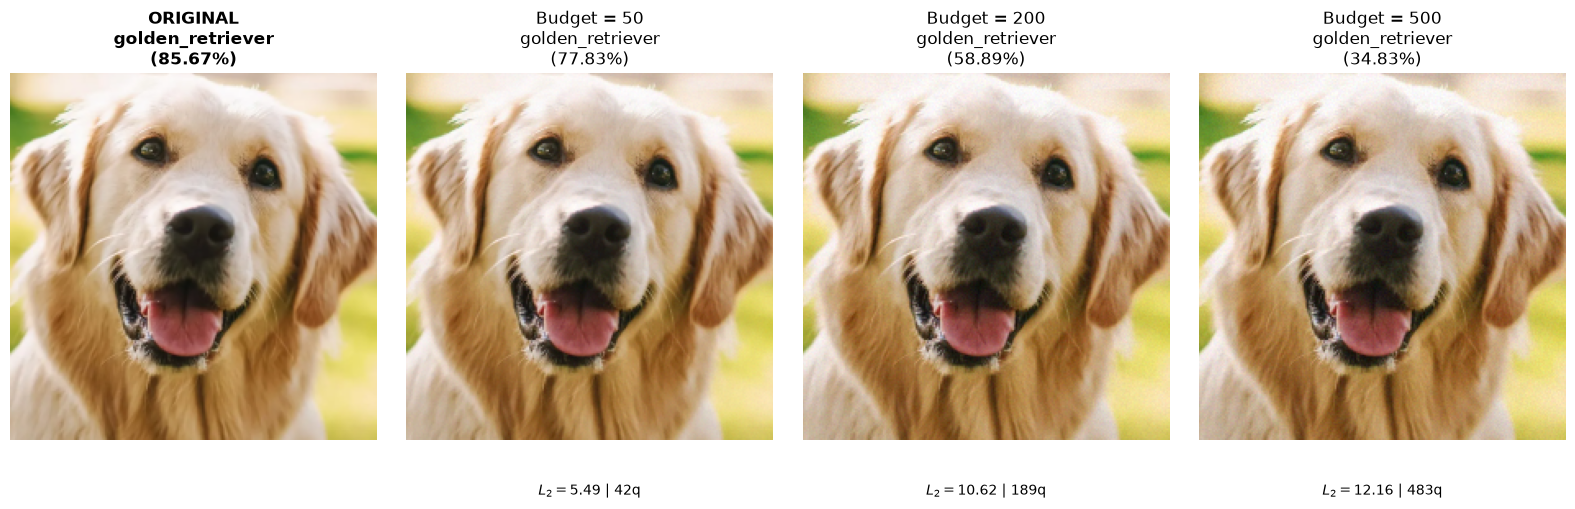


EXECUTING NES ATTACKS ON MODEL: EfficientNetB0

--- Target Image: Dog ---


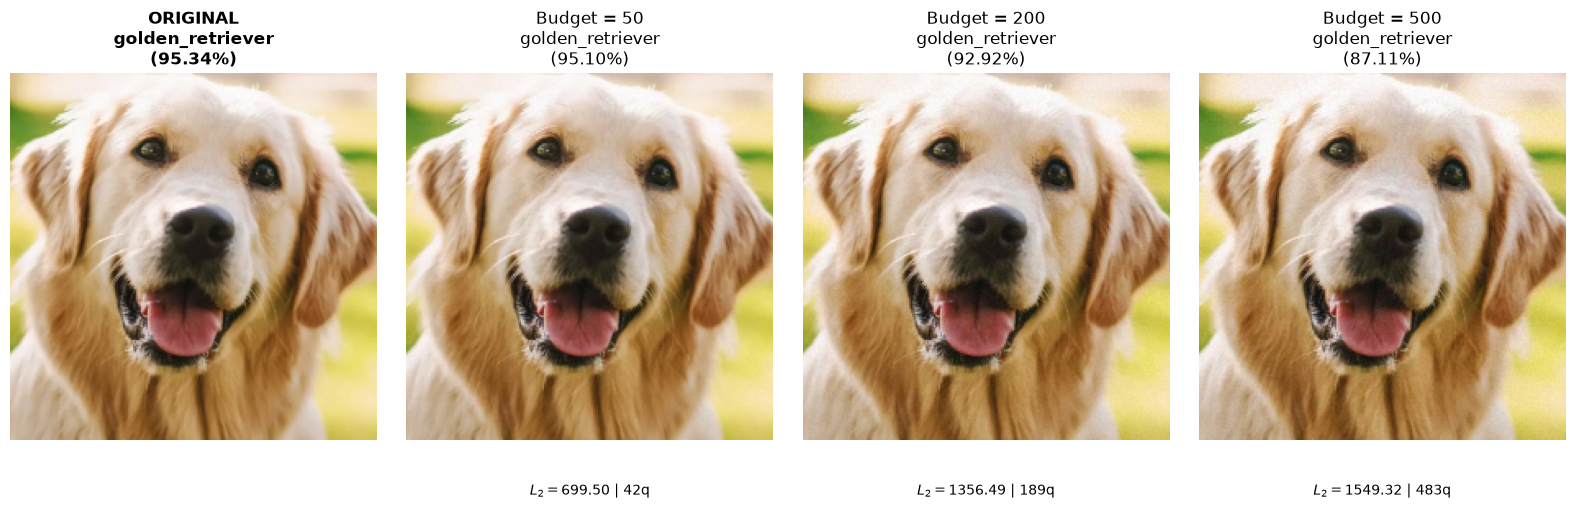


EXECUTING NES ATTACKS ON MODEL: InceptionV3

--- Target Image: Dog ---


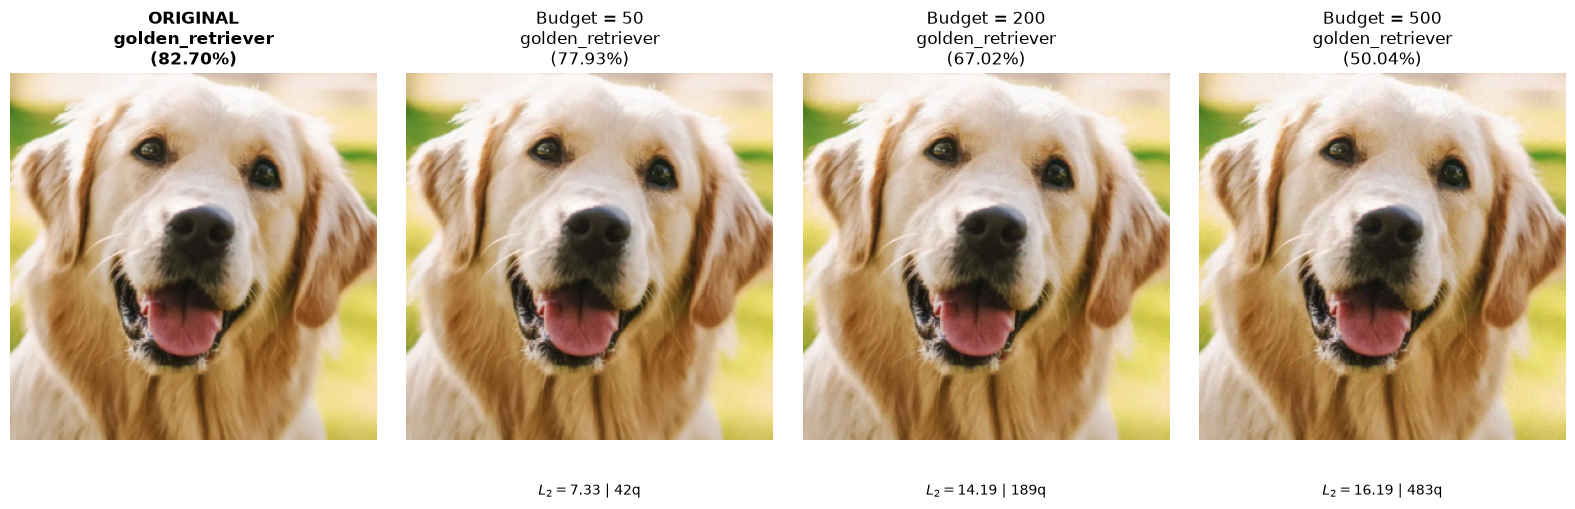

In [5]:
query_budgets = [50, 200, 500]  # dropped 1000 (and, before that, 2000) to keep this tractable on CPU
num_cols = len(query_budgets) + 1 # +1 to include the original image as a baseline
BASE_EPSILON = 0.05

for model_name, m_config in models_dict.items():
    # Print a clear header when switching models
    print(f"\n{'='*80}")
    print(f"EXECUTING NES ATTACKS ON MODEL: {model_name}")
    print(f"{'='*80}\n")

    current_model = m_config['model']
    target_size = m_config['target_size']
    preprocess_fn = m_config['preprocess_fn']
    decode_fn = m_config['decode_fn']
    denormalize_fn = m_config['denormalize_fn'] # Dynamic denormalization function
    clip_min = m_config['clip_min']
    clip_max = m_config['clip_max']

    for img_name, img_path in images_dict.items():
        print(f"--- Target Image: {img_name} ---")

        # Create a new figure for this specific model and image
        fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 4.5))
        fig.subplots_adjust(wspace=0.1)

        # Load and Preprocess
        input_img = load_and_preprocess_image(img_path, target_size, preprocess_fn)

        # Get Original Prediction
        original_probs = current_model.predict(input_img, verbose=0)
        _, orig_class_name, orig_prob = get_imagenet_label(original_probs, decode_fn)
        true_idx = get_imagenet_class_index(original_probs)

        # Plot Original Image in the first column
        ax_orig = axes[0]
        ax_orig.imshow(denormalize_fn(input_img)) # Apply specific denormalization
        ax_orig.set_title(f'ORIGINAL\n{orig_class_name}\n({orig_prob * 100:.2f}%)', fontweight='bold')
        ax_orig.axis('off')

        # Iterate over query budgets
        for col_idx, query_budget in enumerate(query_budgets, start=1):
            # Execute NES Attack
            eps = BASE_EPSILON * m_config['eps_scale']
            adv_img, queries_used = nes_attack(input_img, true_idx, current_model, eps, clip_min, clip_max, query_budget=query_budget)

            # Calculate L2 Distance
            l2 = euclidean_distance(input_img, adv_img)

            # Get Adversarial Prediction
            adv_img_probs = current_model.predict(adv_img, verbose=0)
            _, adv_img_class, adv_class_prob = get_imagenet_label(adv_img_probs, decode_fn)

            # Plot Adversarial Image
            ax = axes[col_idx]
            ax.imshow(denormalize_fn(adv_img))
            ax.set_title(f'Budget = {query_budget}\n{adv_img_class}\n({adv_class_prob * 100:.2f}%)')
            ax.text(0.5, -0.15, f'$L_2={l2:.2f}$ | {queries_used}q', transform=ax.transAxes, ha='center', fontsize=10)
            ax.axis('off')

        plt.tight_layout()
        plt.show()